# Test 

In [ ]:
import pretty_midi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np
import os

# 한글 폰트 설정
_korean_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_korean_font):
    plt.rcParams["font.family"] = fm.FontProperties(fname=_korean_font).get_name()
    fm.fontManager.addfont(_korean_font)

MIDI_PATH = "/home/sangheon/Desktop/Pansori_Data/rosvot_midi/01-김소희-춘향가_어사또_방자_만나는_대목_vocal_000_우조.mid"

midi = pretty_midi.PrettyMIDI(MIDI_PATH)

filename = os.path.basename(MIDI_PATH).replace(".mid", "")
total_time = midi.get_end_time()

print(f"파일: {filename}")
print(f"총 길이: {total_time:.2f}초")
print(f"트랙 수: {len(midi.instruments)}")
for i, inst in enumerate(midi.instruments):
    print(f"  트랙 {i}: {inst.name!r}, 노트 수={len(inst.notes)}, program={inst.program}")

fig, ax = plt.subplots(figsize=(18, 6))

colors = plt.cm.tab10.colors

for inst_idx, inst in enumerate(midi.instruments):
    color = colors[inst_idx % len(colors)]
    for note in inst.notes:
        start = note.start
        duration = note.end - note.start
        pitch = note.pitch
        rect = mpatches.FancyBboxPatch(
            (start, pitch - 0.4),
            duration,
            0.8,
            boxstyle="round,pad=0.02",
            linewidth=0.3,
            edgecolor="black",
            facecolor=color,
            alpha=0.85,
        )
        ax.add_patch(rect)

# pitch 범위 계산
all_pitches = [n.pitch for inst in midi.instruments for n in inst.notes]
if all_pitches:
    p_min, p_max = min(all_pitches) - 2, max(all_pitches) + 2
else:
    p_min, p_max = 48, 84

ax.set_xlim(0, total_time)
ax.set_ylim(p_min, p_max)

# Y축: MIDI pitch → 음이름
note_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
yticks = list(range(int(p_min), int(p_max) + 1))
ylabels = [f"{note_names[p % 12]}{p // 12 - 1}" for p in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=7)

# 반음 경계선 (흰건반/검은건반 구분용 수평선)
for p in yticks:
    if note_names[p % 12] in ["C", "F"]:  # 옥타브/4도 경계
        ax.axhline(p - 0.5, color="gray", linewidth=0.4, alpha=0.5)

ax.set_xlabel("Time (seconds)", fontsize=12)
ax.set_ylabel("MIDI Pitch", fontsize=12)
ax.set_title(f"Piano Roll — {filename}", fontsize=11, pad=10)
ax.grid(axis="x", linestyle="--", alpha=0.3)

if len(midi.instruments) > 1:
    handles = [
        mpatches.Patch(color=colors[i % len(colors)], label=inst.name or f"Track {i}")
        for i, inst in enumerate(midi.instruments)
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8)

plt.tight_layout()
out_path = "/home/sangheon/Desktop/piano_roll.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"\n저장 완료: {out_path}")
plt.show()


파일       : 0a3e284f-01-이일주-심청가_인당수로_향함_vocal
fs         : 100 Hz  →  1 frame = 10 ms
Roll shape : (128, 104053)  (128 pitches × 104053 frames)
Active pitch range: (42, 80)  (F#2 ~ G#5)
Cropped shape: (39, 104053)
Non-zero frames: 90797


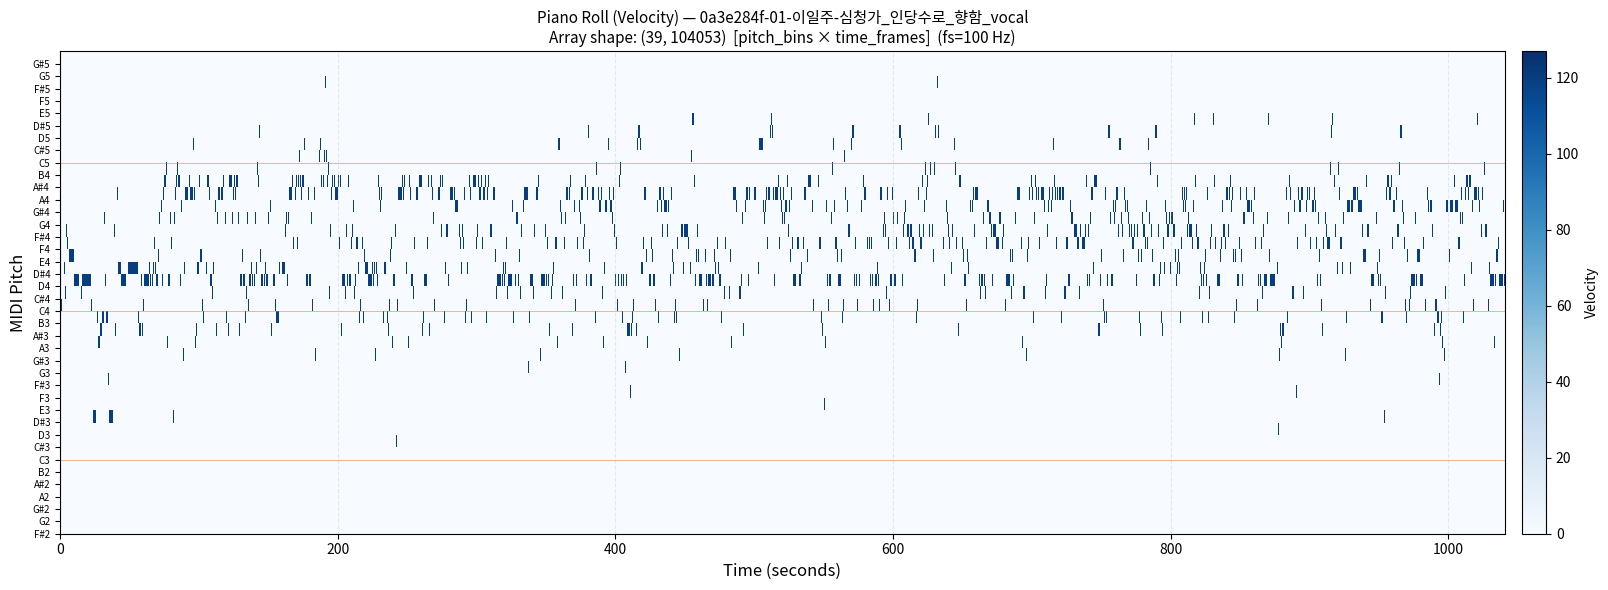

In [ ]:
import pretty_midi
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

_korean_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_korean_font):
    plt.rcParams["font.family"] = fm.FontProperties(fname=_korean_font).get_name()
    fm.fontManager.addfont(_korean_font)

NOTE_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

class PianoRollGenerator:
    """
    Class that returns a 2D numpy array from a MIDI
    Piano roll shape: (128, T)
      - axis 0: MIDI pitch 0~127
      - axis 1: time frame (1 frame = 1/fs)
      - 값: velocity (0이면 무음, 1~127이면 발음 중)
    """
    def __init__(self, midi_path: str, fs: int = 100):
        """
        Args:
            midi_path: MIDI file path
            fs: frames per second
        """
        self.midi = pretty_midi.PrettyMIDI(midi_path)
        self.fs = fs
        self.filename = os.path.basename(midi_path).replace(".mid", "")
        self._roll: np.ndarray | None = None  # (128, T), float32

    @property
    def roll(self) -> np.ndarray: # Uses get piano roll method to generate the piano roll
        if self._roll is None:
            self._roll = self.midi.get_piano_roll(fs=self.fs).astype(np.float32)
        return self._roll

    @property
    def active_pitch_range(self) -> tuple[int, int]:
        """실제로 사용된 pitch 범위 (min, max) 반환."""
        active = np.any(self.roll > 0, axis=1)
        p_min = int(np.argmax(active))
        p_max = int(127 - np.argmax(active[::-1]))
        return max(0, p_min - 2), min(127, p_max + 2)

    def to_binary(self) -> np.ndarray:
        """Velocity 정보를 버리고 0/1 이진 배열로 변환."""
        return (self.roll > 0).astype(np.uint8)

    def crop(self) -> np.ndarray:
        """활성 pitch 범위만 잘라낸 배열 반환."""
        p_min, p_max = self.active_pitch_range
        return self.roll[p_min : p_max + 1, :]

    def plot(self, figsize: tuple = (18, 6), binary: bool = False) -> tuple:
        """Piano roll 2D 배열을 imshow로 시각화.

        Args:
            figsize: 그림 크기
            binary: True면 0/1 이진, False면 velocity 값 표시
        """
        data = self.crop()
        if binary:
            data = (data > 0).astype(np.float32)

        p_min, p_max = self.active_pitch_range
        total_time = self.midi.get_end_time()

        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(
            data,
            aspect="auto",
            origin="lower",
            cmap="Blues",
            interpolation="nearest",
            extent=[0, total_time, p_min, p_max + 1],
            vmin=0,
            vmax=127 if not binary else 1,
        )
        plt.colorbar(im, ax=ax, label="Velocity" if not binary else "On/Off", pad=0.01)

        # Y축 레이블: pitch → 음이름
        yticks = list(range(p_min, p_max + 1))
        ylabels = [f"{NOTE_NAMES[p % 12]}{p // 12 - 1}" for p in yticks]
        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, fontsize=7)

        # C음에 수평 강조선
        for p in yticks:
            if NOTE_NAMES[p % 12] == "C":
                ax.axhline(p, color="tomato", linewidth=0.6, alpha=0.6)

        ax.set_xlabel("Time (seconds)", fontsize=12)
        ax.set_ylabel("MIDI Pitch", fontsize=12)
        mode = "Binary" if binary else "Velocity"
        ax.set_title(
            f"Piano Roll ({mode}) — {self.filename}\n"
            f"Array shape: {data.shape}  [pitch_bins × time_frames]  (fs={self.fs} Hz)",
            fontsize=11,
        )
        ax.grid(axis="x", linestyle="--", alpha=0.25)
        plt.tight_layout()
        return fig, ax


# ── 실행 ──────────────────────────────────────────────────────────────────────
MIDI_PATH = "/home/sangheon/Desktop/Pansori_Data/rosvot_midi_full/midi/0a3e284f-01-이일주-심청가_인당수로_향함_vocal.mid"

gen = PianoRollGenerator(MIDI_PATH, fs=100)

roll = gen.roll          # (128, T) float32
binary = gen.to_binary() # (128, T) uint8

print(f"파일       : {gen.filename}")
print(f"fs         : {gen.fs} Hz  →  1 frame = {1000/gen.fs:.0f} ms")
print(f"Roll shape : {roll.shape}  (128 pitches × {roll.shape[1]} frames)")
print(f"Active pitch range: {gen.active_pitch_range}  ({NOTE_NAMES[gen.active_pitch_range[0]%12]}{gen.active_pitch_range[0]//12-1} ~ {NOTE_NAMES[gen.active_pitch_range[1]%12]}{gen.active_pitch_range[1]//12-1})")
print(f"Cropped shape: {gen.crop().shape}")
print(f"Non-zero frames: {np.sum(roll > 0)}")

fig, ax = gen.plot(binary=False)
plt.savefig("/home/sangheon/Desktop/piano_roll_2d.png", dpi=150, bbox_inches="tight")
plt.show()

# Dataset 

In [1]:
import os
import json
import unicodedata
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset
from tqdm import tqdm
import pretty_midi
import random

class PianoRollGenerator:
    def __init__(self, midi_path: str, fs: int = 100):
        self.midi = pretty_midi.PrettyMIDI(midi_path)
        self.fs = fs
        self.filename = os.path.basename(midi_path)
        self._roll: np.ndarray = None

    def generate_piano_roll(self) -> np.ndarray:
        if self._roll is None:
            self._roll = self.midi.get_piano_roll(fs=self.fs)
        return self._roll

class BaseDataset(Dataset):
    # 아니리, 평조, 창조, 설렁제, 경드름 → others
    label_map = {"우조": 0, "계면조": 1, "others": 2}

    def __init__(self, data_dir, label_json, song_list=None, fs=100, window_size=30.0, is_train=True):
        self.data_dir = Path(data_dir)
        self.song_list = set(song_list) if song_list is not None else None
        self.fs = fs
        self.window_size = int(window_size * fs)  # convert seconds → frames (30s * 100fps = 3000)
        self.is_train = is_train

        with open(label_json, 'r', encoding='utf-8') as f:
            raw = json.load(f)

        self.memory_cache = []
        self.training_instances = []

        for song_idx, item in enumerate(tqdm(raw)):
            fu = unicodedata.normalize('NFC', item['file_upload'])
            midi_name = fu.rsplit('.', 1)[0] + '_vocal.mid'

            if self.song_list is not None and midi_name not in self.song_list:
                continue

            midi_path = self.data_dir / midi_name
            if not midi_path.exists():
                continue

            result = item['annotations'][0]['result']
            if not result:
                continue
            original_length = result[0]['original_length']

            gen = PianoRollGenerator(str(midi_path), fs=self.fs)
            piano_roll = torch.tensor(gen.generate_piano_roll(), dtype=torch.float32)
            frame_label = self.build_frame_label(original_length, result)

            T = min(piano_roll.shape[1], frame_label.shape[0])

            cache_idx = len(self.memory_cache)
            self.memory_cache.append({
                'song_name': midi_name,
                'piano_roll': piano_roll[:, :T],
                'frame_label': frame_label[:T, :],
                'total_frames': T,
            })

            if self.is_train:
                num_repeats = max(1, T // self.window_size)
                for _ in range(num_repeats):
                    self.training_instances.append(cache_idx)

        if not self.is_train:
            self.val_segments = self.prepare_val_segments()

    def build_frame_label(self, original_length: float, result: list) -> torch.Tensor:
        num_frames = int(original_length * self.fs)
        frame_label = torch.zeros(num_frames, 3)
        frame_label[:, 2] = 1  # default: others
        for ann in result:
            val = ann['value']
            s = int(val['start'] * self.fs)
            e = min(int(val['end'] * self.fs), num_frames)
            name = val['labels'][0]
            if name in self.label_map:
                frame_label[s:e, :] = 0
                frame_label[s:e, self.label_map[name]] = 1
        return frame_label

    def prepare_val_segments(self):
        segments = []
        for idx, item in enumerate(self.memory_cache):
            for start in range(0, item['total_frames'], self.window_size):
                segments.append((idx, start))
        return segments

    def __len__(self):
        return len(self.training_instances) if self.is_train else len(self.val_segments)

    def __getitem__(self, idx):
        if self.is_train:
            song_idx = self.training_instances[idx]
            item = self.memory_cache[song_idx]
            if item['total_frames'] > self.window_size:
                start_frame = random.randint(0, item['total_frames'] - self.window_size)
            else:
                start_frame = 0
        else:
            song_idx, start_frame = self.val_segments[idx]
            item = self.memory_cache[song_idx]

        end_frame = start_frame + self.window_size
        slice_piano = item['piano_roll'][:, start_frame:end_frame]
        slice_label = item['frame_label'][start_frame:end_frame, :]

        curr_w = slice_piano.shape[1]
        if curr_w < self.window_size:
            pad_w = self.window_size - curr_w
            slice_piano = torch.nn.functional.pad(slice_piano, (0, pad_w), value=0)
            pad_label = torch.zeros((pad_w, 3))
            pad_label[:, 2] = 1
            slice_label = torch.cat([slice_label, pad_label], dim=0)

        return item['song_name'], slice_piano, slice_label


## Test Code 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

MIDI_DIR   = "/home/sangheon/Desktop/Pansori_Data/rosvot_midi_full/midi"
LABEL_JSON = "/home/sangheon/Desktop/Pansori_Data/labels_2.json"

ds = BaseDataset(MIDI_DIR, LABEL_JSON, fs=100, window_size=30.0, is_train=True)

LABEL_NAMES  = ["우조", "계면조", "others"]
LABEL_COLORS = ["#4C72B0", "#DD8452", "#AAAAAA"]

def visualize_sample(ds, idx):
    song_name, slice_piano, slice_label = ds[idx]

    piano = slice_piano.numpy()        # (128, W)
    label = slice_label.numpy()        # (W, 3)
    W     = piano.shape[1]
    t     = np.arange(W) / ds.fs

    fig, (ax_pr, ax_lbl) = plt.subplots(2, 1, figsize=(16, 5),
                                         gridspec_kw={'height_ratios': [4, 1]})
    # Piano roll
    ax_pr.imshow(piano, aspect='auto', origin='lower',
                 extent=[0, W / ds.fs, 0, 128],
                 cmap='Blues', vmin=0, vmax=127)
    ax_pr.set_ylabel("MIDI pitch")
    ax_pr.set_xlim(0, W / ds.fs)

    cls_idx = label.argmax(axis=1)
    for cls, color in enumerate(LABEL_COLORS):
        changes = np.diff((cls_idx == cls).astype(int), prepend=0, append=0)
        for s, e in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
            ax_lbl.axvspan(s / ds.fs, e / ds.fs, color=color, alpha=0.8)

    ax_lbl.set_xlim(0, W / ds.fs)
    ax_lbl.set_yticks([])
    ax_lbl.set_xlabel("Time (s)")
    handles = [mpatches.Patch(color=c, label=n) for c, n in zip(LABEL_COLORS, LABEL_NAMES)]
    ax_lbl.legend(handles=handles, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

for i in range(min(3, len(ds))):
    visualize_sample(ds, i)


  0%|          | 0/396 [00:00<?, ?it/s]

/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) De

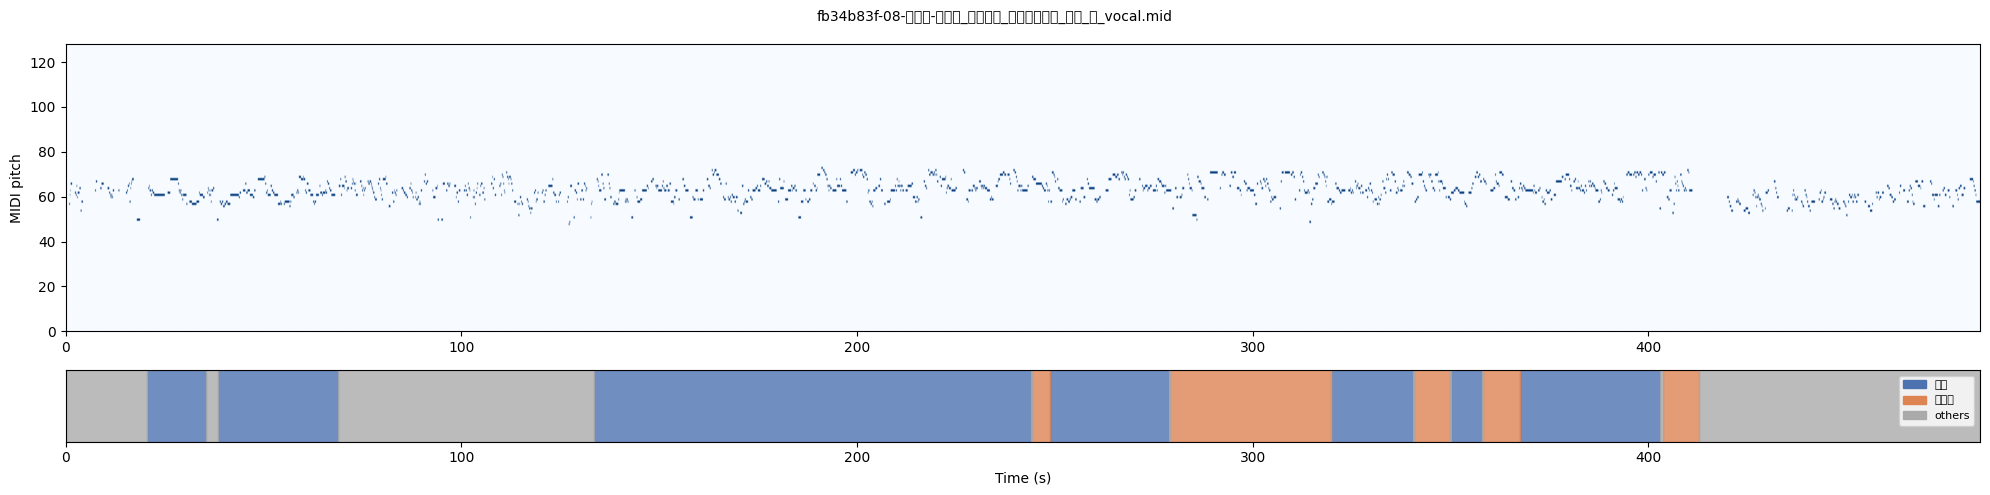

/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missi

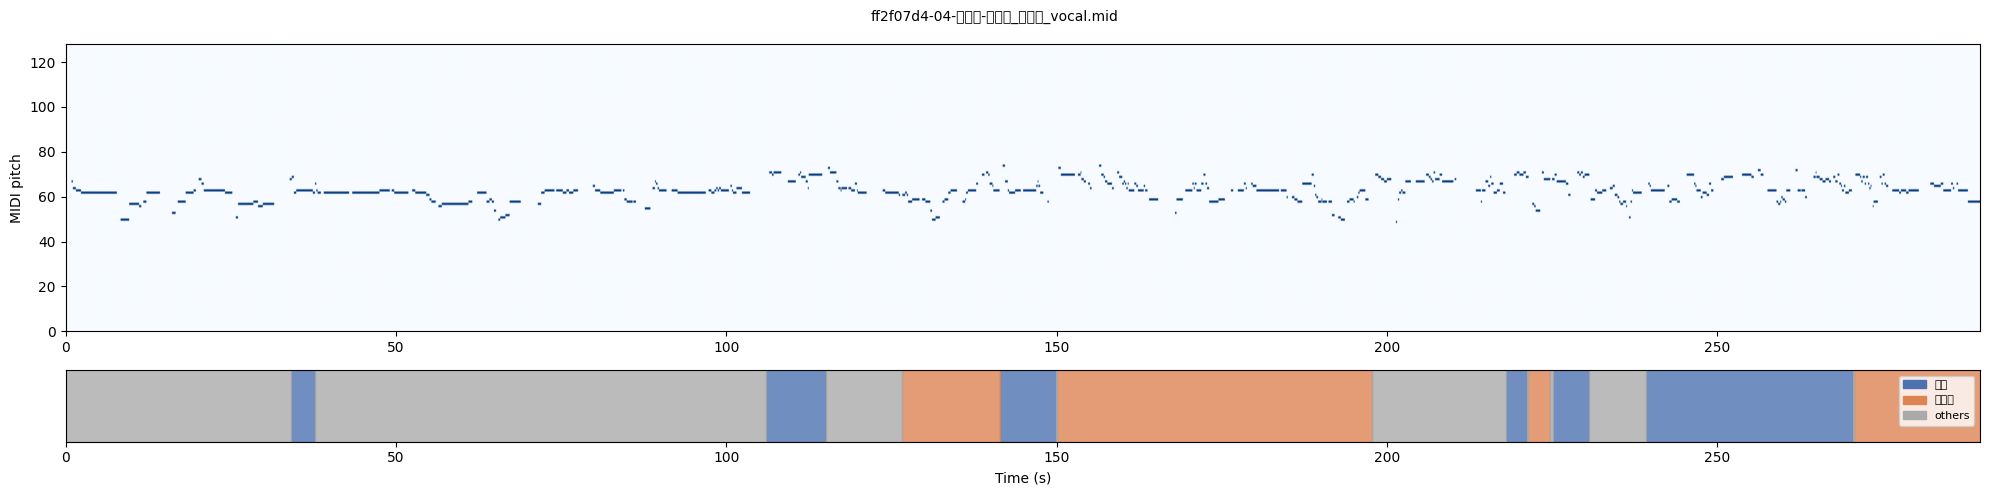

/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2248944/1379734033.py:29: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) Dej

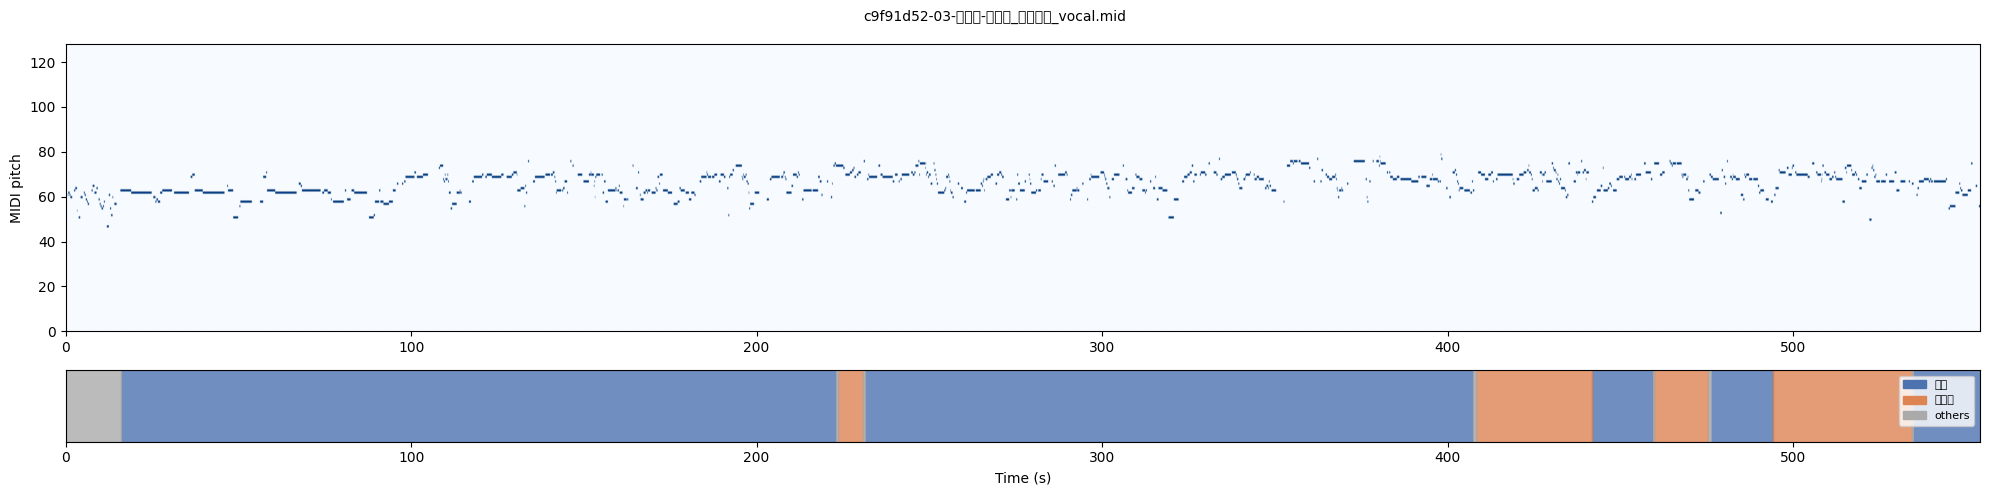

In [17]:
def visualize_song(ds, song_idx):
    item = ds.memory_cache[song_idx]
    piano = item['piano_roll'].numpy()   # (128, T) 전체
    label = item['frame_label'].numpy()  # (T, 3)  전체
    T = item['total_frames']

    fig, (ax_pr, ax_lbl) = plt.subplots(2, 1, figsize=(20, 5),
                                         gridspec_kw={'height_ratios': [4, 1]})
    fig.suptitle(item['song_name'], fontsize=10)

    ax_pr.imshow(piano, aspect='auto', origin='lower',
                 extent=[0, T / ds.fs, 0, 128],
                 cmap='Blues', vmin=0, vmax=127)
    ax_pr.set_ylabel("MIDI pitch")
    ax_pr.set_xlim(0, T / ds.fs)

    cls_idx = label.argmax(axis=1)
    for cls, color in enumerate(LABEL_COLORS):
        changes = np.diff((cls_idx == cls).astype(int), prepend=0, append=0)
        for s, e in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
            ax_lbl.axvspan(s / ds.fs, e / ds.fs, color=color, alpha=0.8)

    ax_lbl.set_xlim(0, T / ds.fs)
    ax_lbl.set_yticks([])
    ax_lbl.set_xlabel("Time (s)")
    ax_lbl.legend(handles=[mpatches.Patch(color=c, label=n)
                            for c, n in zip(LABEL_COLORS, LABEL_NAMES)],
                  loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

for i in range(min(3, len(ds.memory_cache))):
    visualize_song(ds, i)


# Model

In [ ]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional


# ── Config ────────────────────────────────────────────────────────────────────
@dataclass
class Conv2DGRUConfig:
    # CNN encoder
    num_layers: int = 3
    in_channels: int = 1          # 1 because piano roll gets unsqueeze(1)
    num_bins: int = 128            # piano roll has 128 MIDI pitches
    last_hidden_dim: int = 128
    use_gradual_size: bool = False
    kernel_size: int = 3
    pool_size: Optional[str] = "(2,1)"   # halve freq, keep time; set None to skip
    dilation: str = "(1,1)"
    cnn_dropout: float = 0.0

    # GRU
    num_gru: int = 3
    hidden_dim: int = 128
    dropout: float = 0.3

    # Output
    num_classes: int = 3           # 우조 / 계면조 / others


# ── Building blocks ───────────────────────────────────────────────────────────
class Conv2DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, dilation):
        super().__init__()
        self.conv_norm = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size,
                      padding=padding, dilation=dilation),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv_norm(x)

# ── Model ─────────────────────────────────────────────────────────────────────
class Conv2DGRU(nn.Module):
    def __init__(self, config: Conv2DGRUConfig):
        super().__init__()
        self.config = config
        self.params = calc_conv_param(config)

        self.kernel_size = config.kernel_size
        self.dilation    = config.dilation
        self.num_classes = config.num_classes
        self.enc         = self._build_enc()

        self.hidden_dim = config.hidden_dim
        self.num_gru    = config.num_gru
        self.dropout    = config.dropout

        if config.pool_size:
            out_freq = config.num_bins // (2 ** config.num_layers)
        else:
            out_freq = config.num_bins

        gru_input = self.params[-1]['output_channel'] * out_freq
        self.gru = nn.GRU(input_size=gru_input, hidden_size=self.hidden_dim,
                          num_layers=self.num_gru, batch_first=True,
                          dropout=self.dropout, bidirectional=True)
        self.fc = nn.Linear(self.hidden_dim * 2, self.num_classes)

    def _build_enc(self):
        enc = nn.Sequential()
        for idx, param in enumerate(self.params):
            enc.add_module(f'conv_{idx}',
                Conv2DBlock(param['input_channel'], param['output_channel'],
                            kernel_size=self.kernel_size, padding='same',
                            dilation=eval(self.dilation)))
            if self.config.cnn_dropout:
                enc.add_module(f'dropout_{idx}', nn.Dropout2d(self.config.cnn_dropout))
            if self.config.pool_size:
                enc.add_module(f'pool_{idx}', nn.MaxPool2d(eval(param['max_pool'])))
        return enc

    def forward(self, x):
        # x: (B, 128, T) from DataLoader → add channel dim
        if x.ndim == 3:
            x = x.unsqueeze(1)          # (B, 1, 128, T)

        x = self.enc(x)                 # (B, C, F, T)
        b, _, _, t = x.shape
        x = x.permute(0, 3, 1, 2)      # (B, T, C, F)
        x = x.reshape(b, t, -1)        # (B, T, C*F)

        x, _ = self.gru(x)             # (B, T, 2*hidden)
        x = self.fc(x)                 # (B, T, num_classes)
        return x


# ── Quick sanity check ────────────────────────────────────────────────────────
cfg   = Conv2DGRUConfig()
model = Conv2DGRU(cfg)

dummy = torch.zeros(2, 128, 3000)   # (batch=2, pitches=128, frames=3000)
out   = model(dummy)

print(f"Input:  {tuple(dummy.shape)}")
print(f"Output: {tuple(out.shape)}   ← (batch, frames, classes)")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Input:  (2, 128, 3000)
Output: (2, 3000, 3)   ← (batch, frames, classes)
Params: 2,563,587


# Train 

In [3]:
def create_kfold_splits(song_list, k=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    song_list_shuffled = song_list.copy()
    random.shuffle(song_list_shuffled)

    # Divide into 10 chunks for 80/10/10 split with 5 folds
    num_chunks = k * 2  # 10 chunks for 5 folds
    chunk_size = len(song_list_shuffled) // num_chunks
    chunks = []

    for i in range(num_chunks):
        start = i * chunk_size
        end = (i + 1) * chunk_size if i < num_chunks - 1 else len(song_list_shuffled)
        chunks.append(song_list_shuffled[start:end])

    folds = []
    for i in range(k):
        # Test: 1 chunk (10%)
        test_idx = i * 2
        test_songs = chunks[test_idx]

        # Val: 1 chunk (10%)
        val_idx = i * 2 + 1
        val_songs = chunks[val_idx]

        # Train: remaining 8 chunks (80%)
        train_songs = []
        for j in range(num_chunks):
            if j != test_idx and j != val_idx:
                train_songs.extend(chunks[j])

        folds.append({
            'train': train_songs,
            'val': val_songs,
            'test': test_songs
        })

    print(f"\nCreated {k}-fold splits for full dataset (80/10/10):")
    for idx, fold in enumerate(folds):
        print(f"  Fold {idx + 1}: Train={len(fold['train'])}, Val={len(fold['val'])}, Test={len(fold['test'])}")

    return folds


In [ ]:
from torch.utils.data import DataLoader, random_split
from pathlib import Path
import torch.nn.functional as F

def get_all_song_names(data_dir, label_json):
    data_dir = Path(data_dir)
    with open(label_json, 'r', encoding='utf-8') as f:
        raw = json.load(f)
    names = []
    for item in raw:
        fu = unicodedata.normalize('NFC', item['file_upload'])
        midi_name = fu.rsplit('.', 1)[0] + '_vocal.mid'
        if (data_dir / midi_name).exists():
            names.append(midi_name)
    return names

def masked_acc(preds, targets, other_class=2):
    mask = targets != other_class
    if mask.sum() == 0:
        return 0.0
    return (preds[mask] == targets[mask]).float().mean().item()

def run_epoch(loader, model, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc = 0.0, 0.0

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for _, piano, label in loader:
            piano = piano.to(device)
            label = label.to(device)

            out = model(piano)
            tgt = label.argmax(dim=-1)

            loss = criterion(out.permute(0,2,1), tgt)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = out.detach().argmax(dim=-1).view(-1)
            total_loss += loss.item()
            total_acc += masked_acc(preds, tgt.view(-1))
    n = len(loader)
    return total_loss / n, total_acc / n

# ── Settings ──────────────────────────────────────────────────────────────────
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE    = 4
NUM_EPOCHS    = 50
LR            = 1e-4
SAVE_PATH     = 'best_model.pt'
OTHERS_CLASS  = 2   # frames labeled 'others' are excluded from masked accuracy

MIDI_DIR   = "/home/sangheon/Desktop/Pansori_Data/rosvot_midi_full/midi"
LABEL_JSON = "/home/sangheon/Desktop/Pansori_Data/labels_2.json"

all_songs = get_all_song_names(MIDI_DIR, LABEL_JSON)
folds = create_kfold_splits(all_songs, k=10, seed=42)

for fold_idx, fold in enumerate(folds):
    train_dataset = BaseDataset(MIDI_DIR, LABEL_JSON, song_list = fold['train'], fs=100, window_size=30, is_train=True)
    val_dataset = BaseDataset(MIDI_DIR, LABEL_JSON, song_list = fold['val'], fs=100, window_size=30, is_train=False)
    test_dataset = BaseDataset(MIDI_DIR, LABEL_JSON, song_list = fold['test'], fs=100, window_size=30, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    model = Conv2DGRU(Conv2DGRUConfig()).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_acc = 0.0
    save_path = f"best_model_fold{fold_idx + 1}.pt"

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = run_epoch(train_loader, model, optimizer, criterion, DEVICE, train=True)
        val_loss, val_acc = run_epoch(val_loader, model, optimizer, criterion, DEVICE, train=False)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            marker = '  ← best'
        else:
            marker = ''

        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train loss {train_loss:.4f}  acc {train_acc:.3f} | "
              f"Val loss {val_loss:.4f}  acc {val_acc:.3f}{marker}")

    # Evaluate on test set
    model.load_state_dict(torch.load(save_path))
    test_loss, test_acc = run_epoch(test_loader, train=False)
    print(f"\nFold {fold_idx + 1} Test acc: {test_acc:.4f}")


Created 10-fold splits for full dataset (80/10/10):
  Fold 1: Train=358, Val=19, Test=19
  Fold 2: Train=358, Val=19, Test=19
  Fold 3: Train=358, Val=19, Test=19
  Fold 4: Train=358, Val=19, Test=19
  Fold 5: Train=358, Val=19, Test=19
  Fold 6: Train=358, Val=19, Test=19
  Fold 7: Train=358, Val=19, Test=19
  Fold 8: Train=358, Val=19, Test=19
  Fold 9: Train=358, Val=19, Test=19
  Fold 10: Train=342, Val=35, Test=19


  0%|          | 0/396 [00:00<?, ?it/s]

100%|██████████| 396/396 [00:00<00:00, 789.32it/s]


Epoch   1/50 | Train loss 0.8651  acc 0.684 | Val loss 0.6893  acc 0.653  ← best
Epoch   2/50 | Train loss 0.7757  acc 0.724 | Val loss 0.6198  acc 0.713  ← best
Epoch   3/50 | Train loss 0.7290  acc 0.738 | Val loss 0.6118  acc 0.713
Epoch   4/50 | Train loss 0.6902  acc 0.754 | Val loss 0.5871  acc 0.726  ← best
Epoch   5/50 | Train loss 0.6714  acc 0.759 | Val loss 0.5729  acc 0.728  ← best
Epoch   6/50 | Train loss 0.6460  acc 0.778 | Val loss 0.5352  acc 0.728  ← best
Epoch   7/50 | Train loss 0.6388  acc 0.777 | Val loss 0.5973  acc 0.664
Epoch   8/50 | Train loss 0.6026  acc 0.788 | Val loss 0.5970  acc 0.685
Epoch   9/50 | Train loss 0.5861  acc 0.789 | Val loss 0.6463  acc 0.681
Epoch  10/50 | Train loss 0.5603  acc 0.808 | Val loss 0.5393  acc 0.716
Epoch  11/50 | Train loss 0.5451  acc 0.816 | Val loss 0.5587  acc 0.689
Epoch  12/50 | Train loss 0.5339  acc 0.813 | Val loss 0.5848  acc 0.691
Epoch  13/50 | Train loss 0.5229  acc 0.815 | Val loss 0.5643  acc 0.706
Epoch  14/5

KeyboardInterrupt: 

# Evaluation — Posteriorgram Visualization & Metrics

/home/sangheon/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Loaded: best_model_fold1.pt  |  device: cuda

Created 10-fold splits for full dataset (80/10/10):
  Fold 1: Train=358, Val=19, Test=19
  Fold 2: Train=358, Val=19, Test=19
  Fold 3: Train=358, Val=19, Test=19
  Fold 4: Train=358, Val=19, Test=19
  Fold 5: Train=358, Val=19, Test=19
  Fold 6: Train=358, Val=19, Test=19
  Fold 7: Train=358, Val=19, Test=19
  Fold 8: Train=358, Val=19, Test=19
  Fold 9: Train=358, Val=19, Test=19
  Fold 10: Train=342, Val=35, Test=19


100%|██████████| 396/396 [00:00<00:00, 821.77it/s] 


Test songs: 19


/tmp/ipykernel_16286/3753197079.py:150: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches="tight")
/tmp/ipykernel_16286/3753197079.py:150: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches="tight")
/tmp/ipykernel_16286/3753197079.py:150: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches="tight")
/tmp/ipykernel_16286/3753197079.py:150: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches="tight")
/tmp/ipykernel_16286/3753197079.py:150: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches="tight")
/tmp/ipykernel_16286/3753197079.py:150: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from 

KeyboardInterrupt: 

/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sangheon/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu S

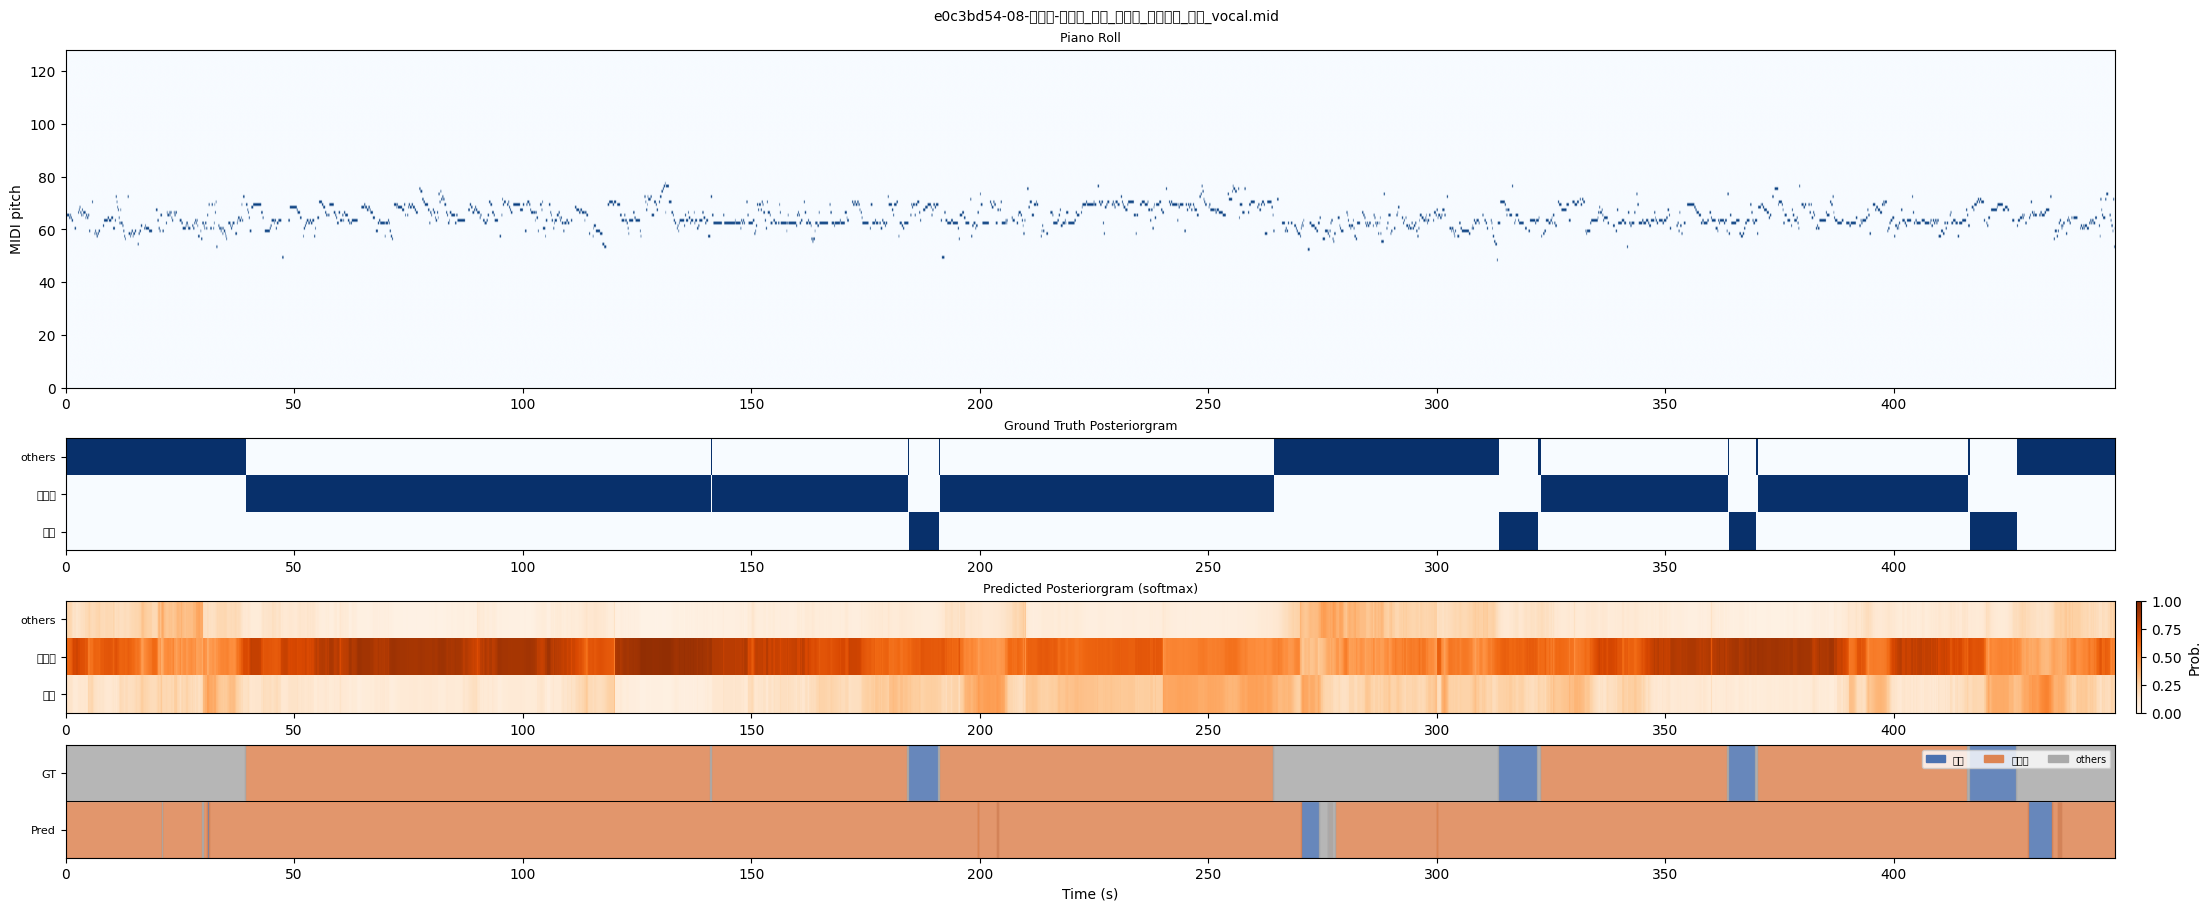

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

LABEL_NAMES  = ["우조", "계면조", "others"]
LABEL_COLORS = ["#4C72B0", "#DD8452", "#AAAAAA"]

# ── Parameters ────────────────────────────────────────────────────────────────
FOLD_IDX   = 1                              # which fold checkpoint to load (1-indexed)
CHECKPOINT = f"best_model_fold{FOLD_IDX}.pt"
MIDI_DIR   = "/home/sangheon/Desktop/Pansori_Data/rosvot_midi_full/midi"
LABEL_JSON = "/home/sangheon/Desktop/Pansori_Data/labels_2.json"
FS         = 100
WINDOW     = 3000   # frames  (30 s × 100 fps)
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ── Load model ────────────────────────────────────────────────────────────────
model = Conv2DGRU(Conv2DGRUConfig()).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()
print(f"Loaded: {CHECKPOINT}  |  device: {DEVICE}")

# ── Build test dataset for this fold ─────────────────────────────────────────
all_songs   = get_all_song_names(MIDI_DIR, LABEL_JSON)
folds       = create_kfold_splits(all_songs, k=10, seed=42)
test_songs  = folds[FOLD_IDX - 1]["test"]
test_ds     = BaseDataset(
    MIDI_DIR, LABEL_JSON,
    song_list=test_songs, fs=FS, window_size=WINDOW / FS, is_train=False,
)
print(f"Test songs: {len(test_ds.memory_cache)}")

# ── Full-song sliding-window inference ────────────────────────────────────────
@torch.no_grad()
def predict_full_song(model, piano_roll, window=WINDOW, device=DEVICE):
    """
    piano_roll : (128, T) float tensor
    Returns    : pred_probs (T, 3) softmax probabilities (numpy)
    """
    T          = piano_roll.shape[1]
    pred_probs = np.zeros((T, 3), dtype=np.float32)
    counts     = np.zeros(T,      dtype=np.float32)

    for start in range(0, T, window):
        end        = min(start + window, T)
        chunk      = piano_roll[:, start:end]       # (128, chunk_len)
        actual_len = chunk.shape[1]

        if actual_len < window:
            chunk = F.pad(chunk, (0, window - actual_len))  # pad to full window

        out   = model(chunk.unsqueeze(0).to(device))        # (1, window, 3)
        probs = F.softmax(out[0], dim=-1).cpu().numpy()     # (window, 3)

        pred_probs[start:end] += probs[:actual_len]
        counts[start:end]     += 1.0

    return pred_probs / np.maximum(counts[:, None], 1.0)

# ── Per-song visualization + collect predictions ───────────────────────────────
all_gt    = []
all_preds = []

for song_idx, item in enumerate(test_ds.memory_cache):
    piano     = item["piano_roll"]          # (128, T) tensor
    gt_onehot = item["frame_label"].numpy() # (T, 3)
    T         = item["total_frames"]

    pred_probs = predict_full_song(model, piano)   # (T, 3)
    pred_cls   = pred_probs.argmax(axis=1)         # (T,)
    gt_cls     = gt_onehot.argmax(axis=1)          # (T,)

    all_gt.extend(gt_cls.tolist())
    all_preds.extend(pred_cls.tolist())

    # ── 4-panel figure ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        4, 1, figsize=(22, 9),
        gridspec_kw={"height_ratios": [3, 1, 1, 1]},
        constrained_layout=True,
    )
    fig.suptitle(item["song_name"], fontsize=10)

    # 1) Piano roll
    ax_pr = axes[0]
    ax_pr.imshow(
        piano.numpy(), aspect="auto", origin="lower",
        extent=[0, T / FS, 0, 128],
        cmap="Blues", vmin=0, vmax=127,
    )
    ax_pr.set_ylabel("MIDI pitch")
    ax_pr.set_xlim(0, T / FS)
    ax_pr.set_title("Piano Roll", fontsize=9)

    # 2) Ground-truth posteriorgram  (one-hot: 0 or 1)
    ax_gt = axes[1]
    ax_gt.imshow(
        gt_onehot.T,              # (3, T)
        aspect="auto", origin="lower",
        extent=[0, T / FS, -0.5, 2.5],
        cmap="Blues", vmin=0, vmax=1,
        interpolation="nearest",
    )
    ax_gt.set_yticks([0, 1, 2])
    ax_gt.set_yticklabels(LABEL_NAMES, fontsize=8)
    ax_gt.set_xlim(0, T / FS)
    ax_gt.set_title("Ground Truth Posteriorgram", fontsize=9)

    # 3) Predicted posteriorgram  (softmax probabilities)
    ax_pred = axes[2]
    im = ax_pred.imshow(
        pred_probs.T,             # (3, T)
        aspect="auto", origin="lower",
        extent=[0, T / FS, -0.5, 2.5],
        cmap="Oranges", vmin=0, vmax=1,
        interpolation="nearest",
    )
    ax_pred.set_yticks([0, 1, 2])
    ax_pred.set_yticklabels(LABEL_NAMES, fontsize=8)
    ax_pred.set_xlim(0, T / FS)
    ax_pred.set_title("Predicted Posteriorgram (softmax)", fontsize=9)
    plt.colorbar(im, ax=ax_pred, fraction=0.015, pad=0.01, label="Prob.")

    # 4) GT (upper half) vs Pred (lower half) label bars
    ax_bar = axes[3]
    for cls, color in enumerate(LABEL_COLORS):
        for seg, ymin, ymax in [(gt_cls, 0.5, 1.0), (pred_cls, 0.0, 0.5)]:
            mask    = (seg == cls).astype(int)
            changes = np.diff(mask, prepend=0, append=0)
            for s, e in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
                ax_bar.axvspan(s / FS, e / FS, ymin=ymin, ymax=ymax,
                               color=color, alpha=0.85)
    ax_bar.axhline(0.5, color="black", linewidth=0.7)
    ax_bar.set_xlim(0, T / FS)
    ax_bar.set_yticks([0.25, 0.75])
    ax_bar.set_yticklabels(["Pred", "GT"], fontsize=8)
    ax_bar.set_xlabel("Time (s)", fontsize=10)
    handles = [mpatches.Patch(color=c, label=n)
               for c, n in zip(LABEL_COLORS, LABEL_NAMES)]
    ax_bar.legend(handles=handles, loc="upper right", fontsize=7, ncol=3)

    save_path = f"test_posteriorgram_fold{FOLD_IDX}_song{song_idx + 1}.png"
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"[{song_idx + 1}/{len(test_ds.memory_cache)}] saved → {save_path}")

# ── Aggregate metrics ─────────────────────────────────────────────────────────
all_gt    = np.array(all_gt)
all_preds = np.array(all_preds)

mask            = all_gt != 2
masked_accuracy = (all_gt[mask] == all_preds[mask]).mean() if mask.sum() > 0 else 0.0

prec, rec, f1, support = precision_recall_fscore_support(
    all_gt, all_preds, labels=[0, 1, 2], average=None, zero_division=0,
)

print("\n" + "═" * 62)
print(f"  Fold {FOLD_IDX} Test Set  —  frame-level metrics")
print("─" * 62)
print(f"{'Metric':<22} {'우조':>10} {'계면조':>10} {'others':>10}")
print("─" * 62)
print(f"{'Precision':<22} {prec[0]:>10.4f} {prec[1]:>10.4f} {prec[2]:>10.4f}")
print(f"{'Recall':<22} {rec[0]:>10.4f} {rec[1]:>10.4f} {rec[2]:>10.4f}")
print(f"{'F1':<22} {f1[0]:>10.4f} {f1[1]:>10.4f} {f1[2]:>10.4f}")
print(f"{'Support (frames)':<22} {support[0]:>10,} {support[1]:>10,} {support[2]:>10,}")
print("─" * 62)
print(f"  Masked accuracy (우조 + 계면조): {masked_accuracy:.4f}")
print("═" * 62)

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm   = confusion_matrix(all_gt, all_preds, labels=[0, 1, 2])
fig2, ax2 = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES).plot(
    ax=ax2, colorbar=True, cmap="Blues",
)
ax2.set_title(
    f"Confusion Matrix — Fold {FOLD_IDX} Test Set (frame-level)", fontsize=10
)
plt.tight_layout()
plt.savefig(f"confusion_matrix_fold{FOLD_IDX}.png", dpi=130, bbox_inches="tight")
plt.show()